# **1. Data-Driven Prioritization of Rare Diseases Using Orphadata**


**Project Overview:**

Rare diseases are difficult to analyse because the data is large, complex, and often incomplete. It can also be challenging to identify which diseases may require more research attention or further investigation. Data analytics methods can help organise and explore rare disease information more effectively.

This notebook presents the Python analysis stage of the project after the SQL data integration process completed in DBeaver. The analysis uses the Orphadata summary dataset and applies different analytical techniques to explore patterns and relationships between diseases.

The workflow includes:
- Data cleaning and validation
- Exploratory Data Analysis
- Feature engineering
- Clustering techniques
- Anomaly detection
- Supporting regression analysis

The main aim of the analysis is to develop a data-based framework which could be applied to support rare disease prioritization and exploration.

# **2. Importing Libraries**

In [121]:
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import skew

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25
})

print('Libraries imported successfully.')

Libraries imported successfully.


# **3. Loading the Dataset**

In [122]:
url = 'https://raw.githubusercontent.com/Jivaish/Rare-diseases/main/Data/Rare_diseases_summary.csv'

df = pd.read_csv(url)

print('Dataset loaded successfully.')
print('Dataset shape:', df.shape)

display(df.head())
df.info()

Dataset loaded successfully.
Dataset shape: (11456, 7)


,OrphaCode,Name,DisorderGroup,gene_count,onset_count,inheritance_count,avg_prevalence
0,5,Long chain 3-hydroxyacyl-CoA dehydrogenase def...,Disorder,1,1,1,1.355833
1,6,3-methylcrotonyl-CoA carboxylase deficiency,Disorder,2,1,1,1.535000
2,7,3C syndrome,Disorder,4,1,1,12.500000
3,8,"47,XYY syndrome",Disorder,0,1,1,16.025000
4,9,Tetrasomy X syndrome,Disorder,0,1,1,25.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11456 entries, 0 to 11455
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   OrphaCode          11456 non-null  int64  
 1   Name               11456 non-null  object 
 2   DisorderGroup      11456 non-null  object 
 3   gene_count         11456 non-null  int64  
 4   onset_count        11456 non-null  int64  
 5   inheritance_count  11456 non-null  int64  
 6   avg_prevalence     6443 non-null   float64
dtypes: float64(1), int64(4), object(2)
memory usage: 626.6+ KB


# **4. Initial Data Checks**

In [123]:
print('Missing values:')
display(df.isnull().sum())

print('\nDuplicate OrphaCode values:', df.duplicated(subset='OrphaCode').sum())
print('Duplicate full rows:', df.duplicated().sum())

print('\nDescriptive summary:')
display(df.describe(include='all').T)

Missing values:


,0
OrphaCode,0
Name,0
DisorderGroup,0
gene_count,0
onset_count,0
inheritance_count,0
avg_prevalence,5013



Duplicate OrphaCode values: 0
Duplicate full rows: 0

Descriptive summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
OrphaCode,11456.0,NaN,NaN,NaN,212643.364787,205123.850994,5.0,57631.75,139460.5,317440.75,718255.0
Name,11456,11456,Developmental delay-facial dysmorphism-Blaschk...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DisorderGroup,11456,3,Disorder,7441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gene_count,11456.0,NaN,NaN,NaN,0.72809,2.658769,0.0,0.0,0.0,1.0,114.0
onset_count,11456.0,NaN,NaN,NaN,0.64368,0.478932,0.0,0.0,1.0,1.0,1.0
inheritance_count,11456.0,NaN,NaN,NaN,0.64368,0.478932,0.0,0.0,1.0,1.0,1.0
avg_prevalence,6443.0,NaN,NaN,NaN,15.797329,182.028565,0.0,0.027581,2.0,8.5,10000.0


## **4.1. Analysing aggregation levels separately**

In [124]:
#Analysing aggregation levels separately

print('DisorderGroup distribution (full dataset):')
display(df['DisorderGroup'].value_counts())

print('\n--- Domain knowledge example: hydroxyglutaric aciduria ---')
example = df[df['Name'].str.contains('hydroxyglutaric aciduria', case=False, na=False)]
display(example[['OrphaCode', 'Name', 'DisorderGroup', 'gene_count', 'avg_prevalence']])

# Cleaning numeric columns before analysis
numeric_cols = ['gene_count', 'onset_count', 'inheritance_count', 'avg_prevalence']
df['has_prevalence_data'] = df['avg_prevalence'].notna().astype(int)
df['avg_prevalence'] = df['avg_prevalence'].fillna(0)
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Computing summary statistics by aggregation level to highlight possible distortion
print('\nMean feature values per DisorderGroup (shows structural zeros in Group of disorders):')
level_summary = df.groupby('DisorderGroup')[numeric_cols + ['has_prevalence_data']].mean().round(3)
display(level_summary)

print('\nProportion of records with gene_count = 0 per aggregation level:')
zero_genes = df.groupby('DisorderGroup').apply(
    lambda x: (x['gene_count'] == 0).mean()
).round(3).rename('pct_zero_gene_count')
display(zero_genes)

DisorderGroup distribution (full dataset):


,count
DisorderGroup,
Disorder,7441
Group of disorders,2633
Subtype of disorder,1382



--- Domain knowledge example: hydroxyglutaric aciduria ---


,OrphaCode,Name,DisorderGroup,gene_count,avg_prevalence
13,19,2-hydroxyglutaric aciduria,Group of disorders,0,0.0
3306,79314,L-2-hydroxyglutaric aciduria,Disorder,1,70.0
3307,79315,D-2-hydroxyglutaric aciduria,Disorder,2,40.0
5159,99646,Metaphyseal chondromatosis with D-2-hydroxyglu...,Disorder,1,0.0
8913,356978,"D,L-2-hydroxyglutaric aciduria",Disorder,1,6.5



Mean feature values per DisorderGroup (shows structural zeros in Group of disorders):


,gene_count,onset_count,inheritance_count,avg_prevalence,has_prevalence_data
DisorderGroup,,,,,
Disorder,0.881,0.820,0.820,12.659,0.746
Group of disorders,0.002,0.127,0.127,1.106,0.121
Subtype of disorder,1.288,0.678,0.678,3.384,0.418



Proportion of records with gene_count = 0 per aggregation level:


,pct_zero_gene_count
DisorderGroup,
Disorder,0.548
Group of disorders,0.998
Subtype of disorder,0.452


## 4.2 Correlation by aggregation level

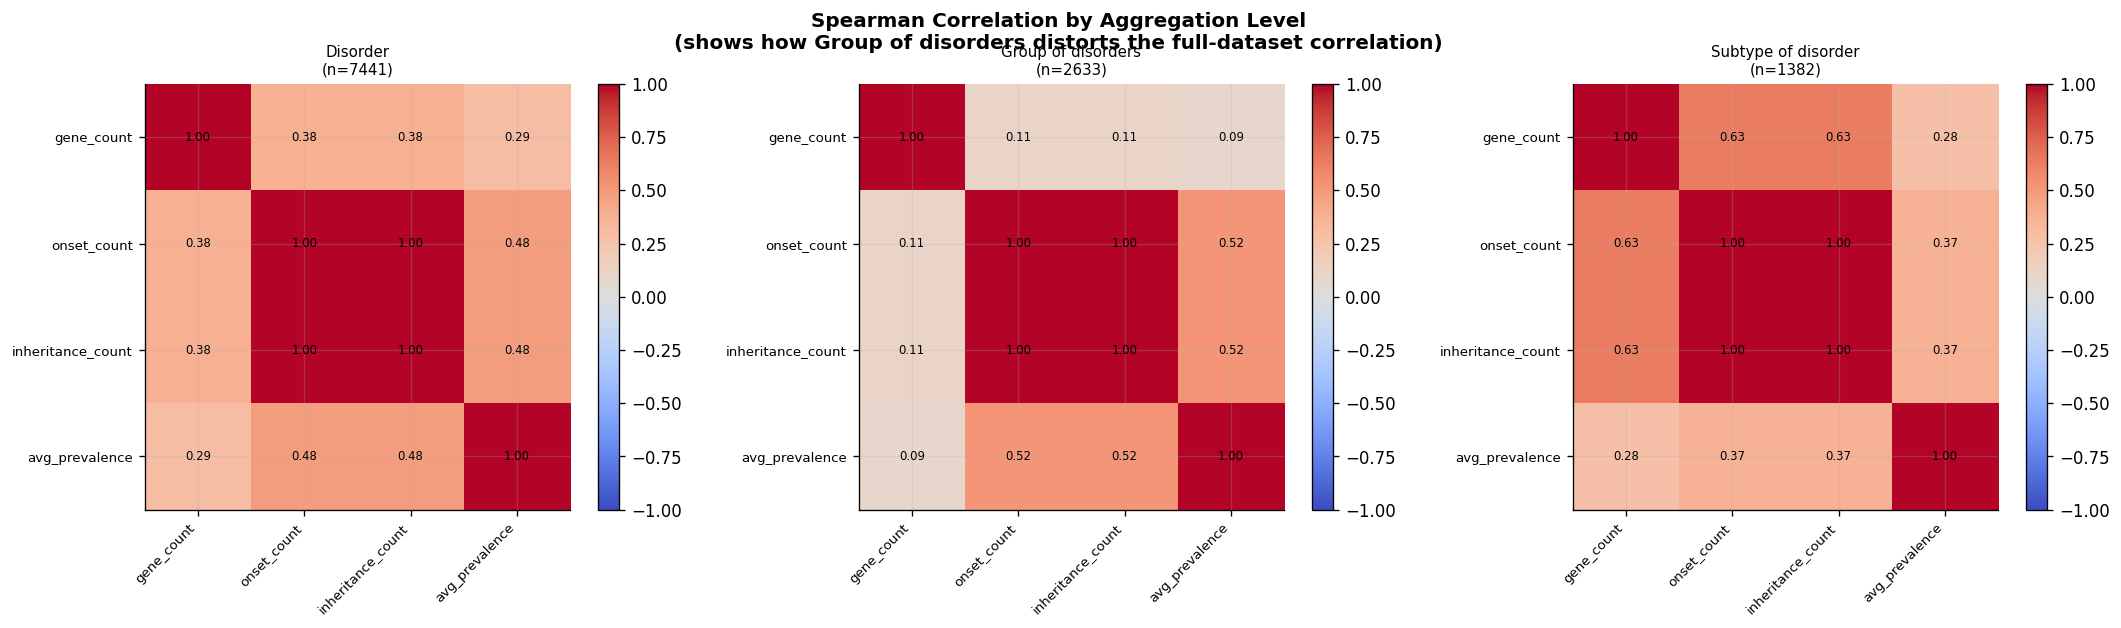


Note: Group of disorders shows near-zero correlations because structural zeros
dominate the distribution. Disorder-level correlations may reflect more biologically meaningful patterns.


In [125]:
# Correlations by aggregation level
corr_cols_base = ['gene_count', 'onset_count', 'inheritance_count', 'avg_prevalence']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Spearman Correlation by Aggregation Level\n(shows how Group of disorders distorts the full-dataset correlation)',
    fontsize=12,
    fontweight='bold'
)

levels = ['Disorder', 'Group of disorders', 'Subtype of disorder']

for ax, level in zip(axes, levels):
    subset = df[df['DisorderGroup'] == level]

    if len(subset) > 10:
        cm = subset[corr_cols_base].corr(method='spearman')
        im = ax.imshow(cm, cmap='coolwarm', vmin=-1, vmax=1)

        ax.set_xticks(range(len(corr_cols_base)))
        ax.set_xticklabels(corr_cols_base, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(corr_cols_base)))
        ax.set_yticklabels(corr_cols_base, fontsize=8)

        for i in range(len(corr_cols_base)):
            for j in range(len(corr_cols_base)):
                ax.text(j, i, f'{cm.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)

        ax.set_title(f'{level}\n(n={len(subset)})', fontsize=9)
        plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('correlation_per_aggregation_level.png', bbox_inches='tight')
plt.show()

print('\nNote: Group of disorders shows near-zero correlations because structural zeros')
print('dominate the distribution. Disorder-level correlations may reflect more biologically meaningful patterns.')

## **4.3 Disorder-Level Filtering for Consistent Analysis**
After identifying aggregation-level differences in the Orphadata structure, the dataset was filtered to retain only records classified as `Disorder`. This ensures that the EDA, feature engineering, and modelling are based on comparable disease-level observations.

In [126]:
# Selecting Disorder-level records to avoid taxonomic group entries and subtype duplication
df = df[df['DisorderGroup'] == 'Disorder'].copy()
df.reset_index(drop=True, inplace=True)

print('Dataset shape after filtering to Disorder only:', df.shape)
print('Remaining DisorderGroup:')
display(df['DisorderGroup'].value_counts())

Dataset shape after filtering to Disorder only: (7441, 8)
Remaining DisorderGroup:


,count
DisorderGroup,
Disorder,7441


# **5. EDA – Disorder Level**

In [127]:
eda_summary = df[numeric_cols].describe().T
eda_summary['skewness'] = df[numeric_cols].apply(skew)

print('EDA summary (Disorder-level only):')
display(eda_summary.round(3))

print('\nPrevalence coverage:')
print(f'  Records with prevalence data: {df["has_prevalence_data"].sum()} / {len(df)} ({df["has_prevalence_data"].mean()*100:.1f}%)')
print(f'  Records with gene data:       {(df["gene_count"] > 0).sum()} / {len(df)} ({(df["gene_count"]>0).mean()*100:.1f}%)')

EDA summary (Disorder-level only):


,count,mean,std,min,25%,50%,75%,max,skewness
gene_count,7441.0,0.881,2.813,0.0,0.0,0.0,1.0,114.0,18.265
onset_count,7441.0,0.820,0.384,0.0,1.0,1.0,1.0,1.0,-1.666
inheritance_count,7441.0,0.820,0.384,0.0,1.0,1.0,1.0,1.0,-1.666
avg_prevalence,7441.0,12.659,169.313,0.0,0.0,1.0,5.0,10000.0,52.292



Prevalence coverage:
  Records with prevalence data: 5548 / 7441 (74.6%)
  Records with gene data:       3366 / 7441 (45.2%)


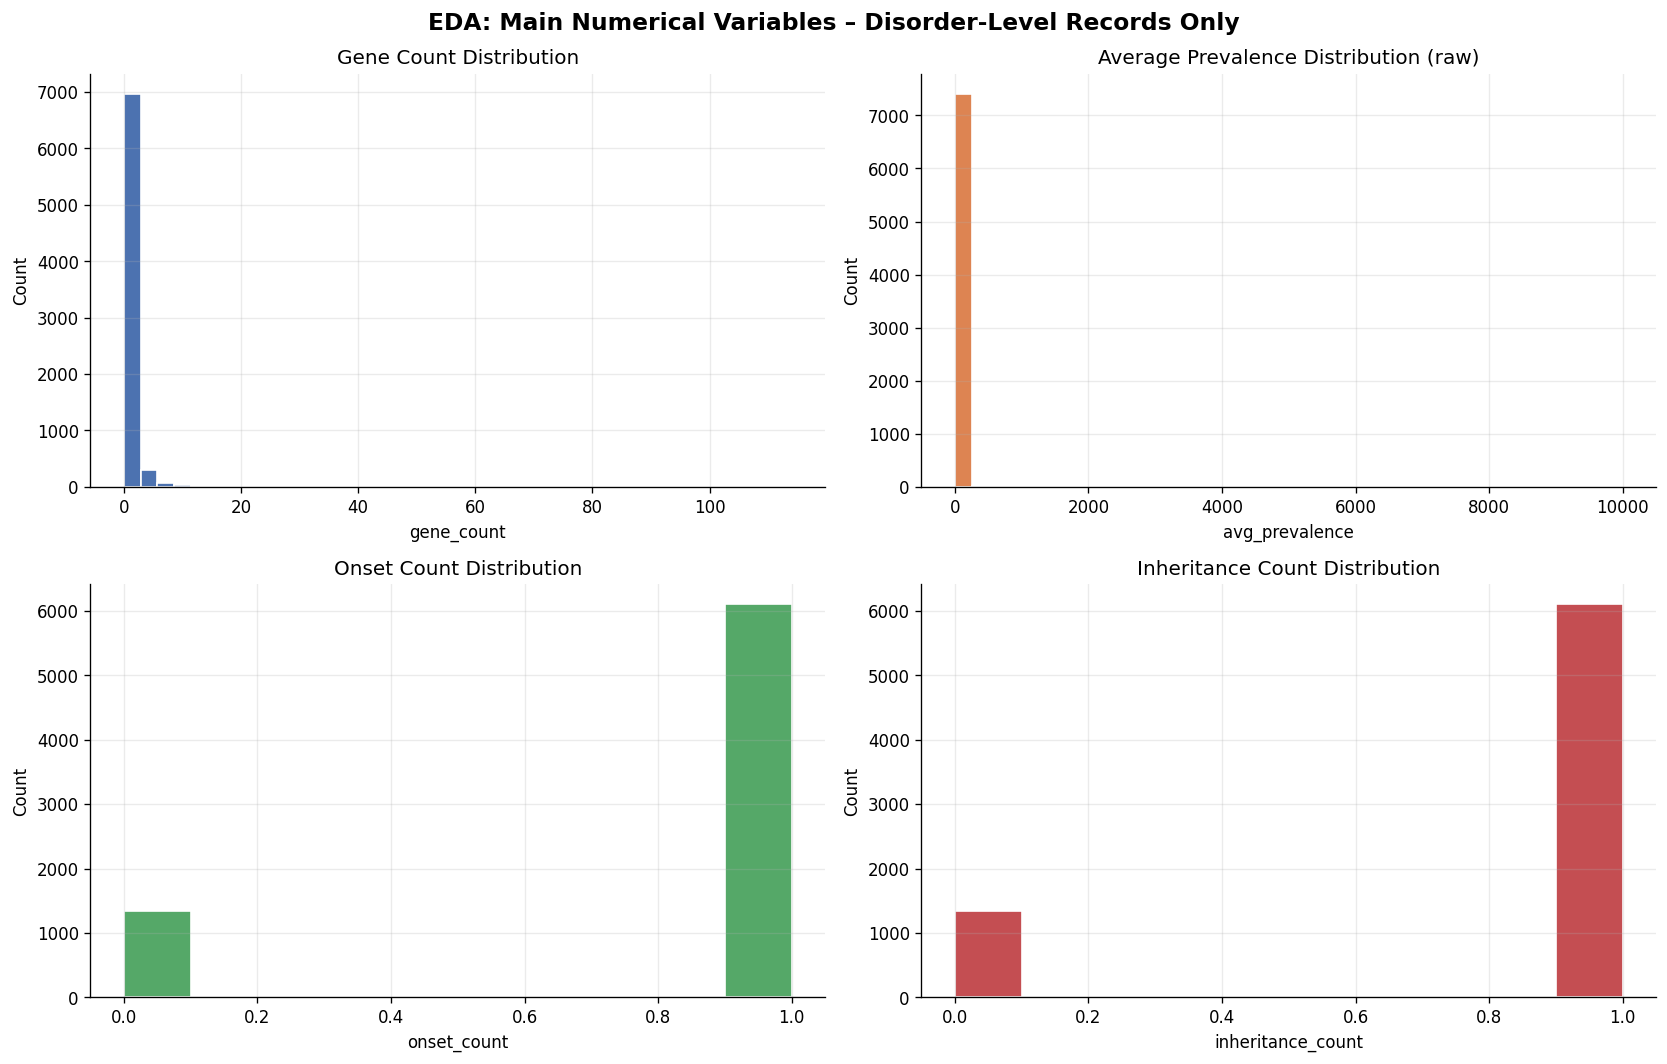

In [128]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('EDA: Main Numerical Variables – Disorder-Level Records Only', fontsize=14, fontweight='bold')

axes[0, 0].hist(df['gene_count'], bins=40, color='#4C72B0', edgecolor='white')
axes[0, 0].set_title('Gene Count Distribution')
axes[0, 0].set_xlabel('gene_count')
axes[0, 0].set_ylabel('Count')

axes[0, 1].hist(df['avg_prevalence'], bins=40, color='#DD8452', edgecolor='white')
axes[0, 1].set_title('Average Prevalence Distribution (raw)')
axes[0, 1].set_xlabel('avg_prevalence')
axes[0, 1].set_ylabel('Count')

axes[1, 0].hist(df['onset_count'], bins=10, color='#55A868', edgecolor='white')
axes[1, 0].set_title('Onset Count Distribution')
axes[1, 0].set_xlabel('onset_count')
axes[1, 0].set_ylabel('Count')

axes[1, 1].hist(df['inheritance_count'], bins=10, color='#C44E52', edgecolor='white')
axes[1, 1].set_title('Inheritance Count Distribution')
axes[1, 1].set_xlabel('inheritance_count')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_main_distributions.png', bbox_inches='tight')
plt.show()

## **5.1. Log Transformation of Prevalence**

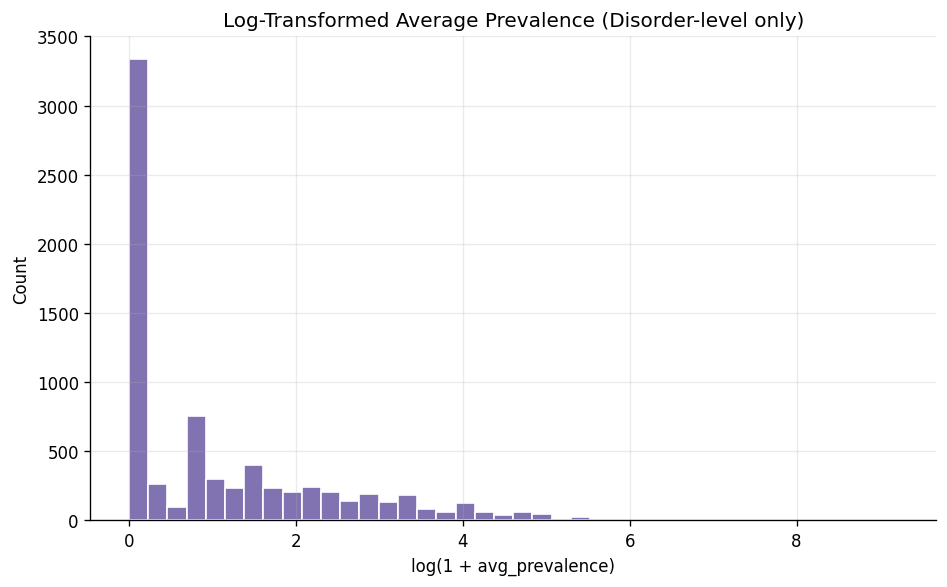

Skewness before log transform: 52.292
Skewness after log transform:  1.274


In [129]:
# Applying log transformation to handle skewed prevalence values
df['log_avg_prevalence'] = np.log1p(df['avg_prevalence'])

plt.figure(figsize=(8, 5))
plt.hist(df['log_avg_prevalence'], bins=40, color='#8172B2', edgecolor='white')
plt.title('Log-Transformed Average Prevalence (Disorder-level only)')
plt.xlabel('log(1 + avg_prevalence)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('log_prevalence_distribution.png', bbox_inches='tight')
plt.show()

print('Skewness before log transform:', round(skew(df['avg_prevalence']), 3))
print('Skewness after log transform: ', round(skew(df['log_avg_prevalence']), 3))

## 5.2. Spearman Correlation – Disorder Level Only

Spearman correlation matrix (Disorder-level only):


,gene_count,onset_count,inheritance_count,avg_prevalence,log_avg_prevalence,has_prevalence_data
gene_count,1.000,0.378,0.378,0.291,0.291,0.314
onset_count,0.378,1.000,1.000,0.483,0.483,0.785
inheritance_count,0.378,1.000,1.000,0.483,0.483,0.785
avg_prevalence,0.291,0.483,0.483,1.000,1.000,0.618
log_avg_prevalence,0.291,0.483,0.483,1.000,1.000,0.618
has_prevalence_data,0.314,0.785,0.785,0.618,0.618,1.000


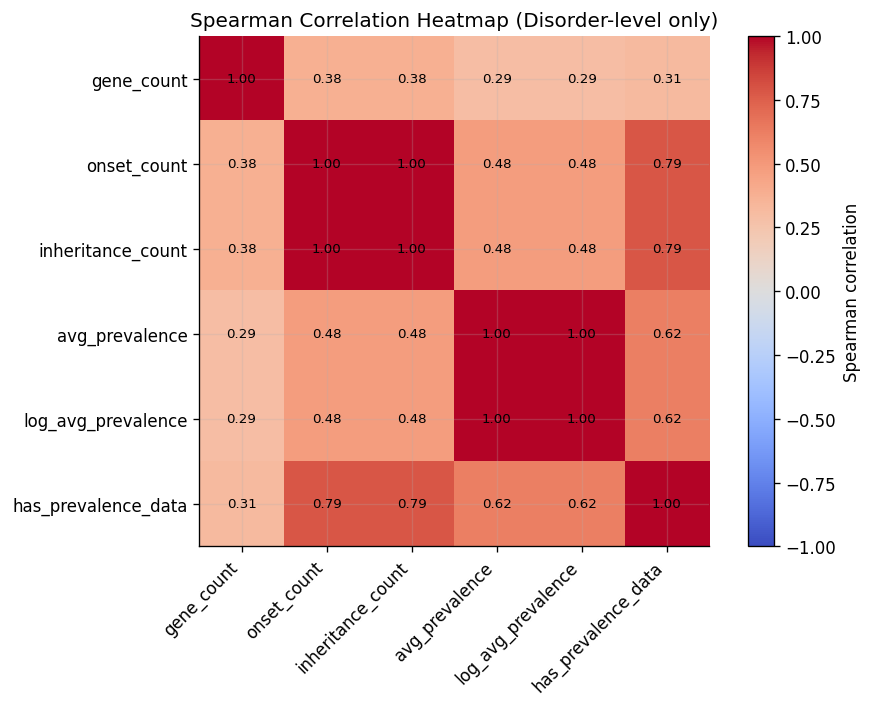

In [130]:
corr_cols = [
    'gene_count',
    'onset_count',
    'inheritance_count',
    'avg_prevalence',
    'log_avg_prevalence',
    'has_prevalence_data'
]

corr_matrix = df[corr_cols].corr(method='spearman')

print('Spearman correlation matrix (Disorder-level only):')
display(corr_matrix.round(3))

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Spearman correlation')
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha='right')
plt.yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f'{corr_matrix.iloc[i,j]:.2f}',
                 ha='center', va='center', fontsize=8)
plt.title('Spearman Correlation Heatmap (Disorder-level only)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

# **6. Feature Engineering**


In [131]:
# Feature engineering for clinical diversity, genetic complexity, prevalence, and data completeness

df['clinical_diversity_score'] = df['onset_count'] + df['inheritance_count']

df['genetic_complexity_score'] = df['gene_count']

df['prevalence_signal'] = df['log_avg_prevalence']

df['has_gene_data'] = (df['gene_count'] > 0).astype(int)
df['has_onset_data'] = (df['onset_count'] > 0).astype(int)
df['has_inheritance_data'] = (df['inheritance_count'] > 0).astype(int)

df['data_completeness_score'] = (
    df['has_gene_data'] +
    df['has_onset_data'] +
    df['has_inheritance_data'] +
    df['has_prevalence_data']
)

print('Engineered feature summary:')
display(df[[
    'gene_count',
    'clinical_diversity_score',
    'prevalence_signal',
    'data_completeness_score'
]].describe().round(2))

Engineered feature summary:


,gene_count,clinical_diversity_score,prevalence_signal,data_completeness_score
count,7441.00,7441.00,7441.00,7441.00
mean,0.88,1.64,1.07,2.84
std,2.81,0.77,1.33,1.41
min,0.00,0.00,0.00,0.00
25%,0.00,2.00,0.00,3.00
50%,0.00,2.00,0.69,3.00
75%,1.00,2.00,1.79,4.00
max,114.00,2.00,9.21,4.00


## 6.1. Priority Score Creation

In [132]:
priority_features = [
    'genetic_complexity_score',
    'clinical_diversity_score',
    'prevalence_signal',
    'data_completeness_score'
]

scaler_priority = MinMaxScaler()
priority_scaled = scaler_priority.fit_transform(df[priority_features])

priority_scaled_df = pd.DataFrame(
    priority_scaled,
    columns=[
        'genetic_complexity_scaled',
        'clinical_diversity_scaled',
        'prevalence_signal_scaled',
        'data_completeness_scaled'
    ],
    index=df.index
)

df = pd.concat([df, priority_scaled_df], axis=1)

# Weights justified in the markdown cell above
df['priority_score'] = (
    0.35 * df['genetic_complexity_scaled'] +
    0.25 * df['clinical_diversity_scaled'] +
    0.30 * df['prevalence_signal_scaled'] +
    0.10 * df['data_completeness_scaled']
)

df['priority_rank'] = df['priority_score'].rank(ascending=False, method='dense').astype(int)

print('Top 20 diseases by priority score:')
display(
    df.sort_values('priority_score', ascending=False)[
        ['OrphaCode', 'Name', 'DisorderGroup', 'gene_count', 'avg_prevalence',
         'priority_score', 'priority_rank']
    ].head(20)
)

Top 20 diseases by priority score:


,OrphaCode,Name,DisorderGroup,gene_count,avg_prevalence,priority_score,priority_rank
613,791,Retinitis pigmentosa,Disorder,88,22.254444,0.722662,1
6658,528084,Non-specific syndromic intellectual disability,Disorder,114,0.000000,0.700000,2
4799,227972,Toxic oil syndrome,Disorder,0,10000.000000,0.625000,3
5558,319218,Ebola hemorrhagic fever,Disorder,0,9406.666667,0.623008,4
4126,103909,Trehalase deficiency,Disorder,1,3850.000000,0.621985,5
195,244,Primary ciliary dyskinesia,Disorder,53,24.500000,0.618209,6
6303,454745,Kuru,Disorder,1,1350.000000,0.587867,7
124,154,Familial isolated dilated cardiomyopathy,Disorder,53,8.803333,0.587072,8
1571,2309,Pachyonychia congenita,Disorder,4,500.045000,0.564769,9
413,536,Systemic lupus erythematosus,Disorder,30,35.980000,0.559702,10


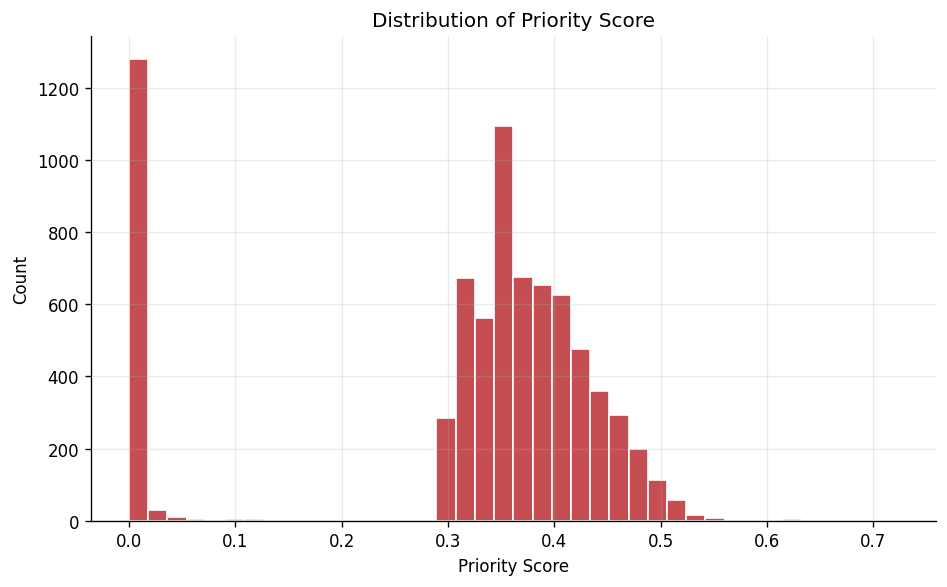

In [133]:
plt.figure(figsize=(8, 5))
plt.hist(df['priority_score'], bins=40, color='#C44E52', edgecolor='white')
plt.title('Distribution of Priority Score')
plt.xlabel('Priority Score')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('priority_score_distribution.png', bbox_inches='tight')
plt.show()

## 6.2 Preparing for Modelling

In [134]:
model_features = [
    'gene_count',
    'onset_count',
    'inheritance_count',
    'log_avg_prevalence',
    'data_completeness_score'
]

X = df[model_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=model_features)

print('Scaled model features (first 5 rows):')
display(X_scaled_df.head())

Scaled model features (first 5 rows):


,gene_count,onset_count,inheritance_count,log_avg_prevalence,data_completeness_score
0,0.042279,0.46844,0.46844,-0.163577,0.822062
1,0.397755,0.46844,0.46844,-0.108492,0.822062
2,1.108708,0.46844,0.46844,1.148418,0.822062
3,-0.313197,0.46844,0.46844,1.322765,0.114571
4,-0.313197,0.46844,0.46844,1.640967,0.114571


## 6.3 PCA

PC1 explained variance: 0.6312
PC2 explained variance: 0.1933
Total explained variance: 0.8244

PCA loadings (which features drive each PC):


,PC1,PC2
gene_count,0.137,0.986
onset_count,0.546,-0.102
inheritance_count,0.546,-0.102
log_avg_prevalence,0.300,-0.084
data_completeness_score,0.543,0.004


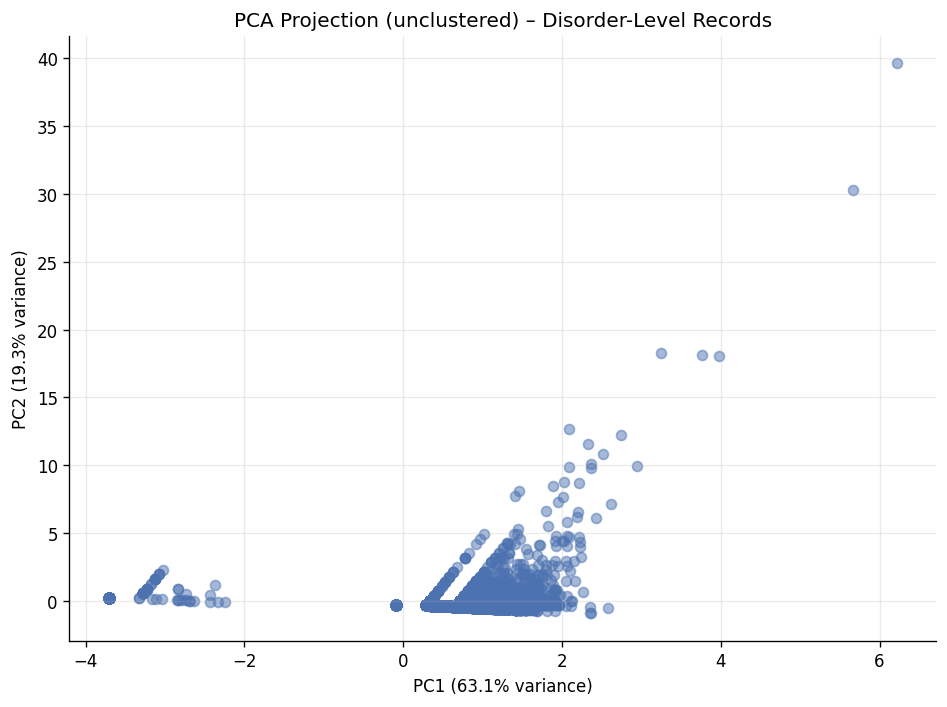

In [135]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

print('PC1 explained variance:', round(pca.explained_variance_ratio_[0], 4))
print('PC2 explained variance:', round(pca.explained_variance_ratio_[1], 4))
print('Total explained variance:', round(pca.explained_variance_ratio_.sum(), 4))

# Loadings: which features drive each PC
loadings = pd.DataFrame(
    pca.components_.T,
    index=model_features,
    columns=['PC1', 'PC2']
).round(3)
print('\nPCA loadings (which features drive each PC):')
display(loadings)

plt.figure(figsize=(8, 6))
plt.scatter(df['PC1'], df['PC2'], alpha=0.5, color='#4C72B0')
plt.title('PCA Projection (unclustered) – Disorder-Level Records')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.tight_layout()
plt.savefig('pca_unclustered.png', bbox_inches='tight')
plt.show()

# **7. K-Means Model Selection**

K-Means validation metrics:


,k,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,2,14818.6915,0.7312,0.2703,11237.9523
1,3,10145.2706,0.5742,0.6826,9919.4135
2,4,6436.0659,0.5779,0.6434,11851.3683
3,5,4855.8933,0.5873,0.6053,12384.3309
4,6,3851.5626,0.5043,0.7004,12876.9972
5,7,3158.3286,0.5281,0.7259,13356.3767
6,8,2528.6242,0.5327,0.6663,14561.8147
7,9,2241.6045,0.5174,0.7139,14490.1389
8,10,1974.6355,0.5481,0.6694,14731.1185


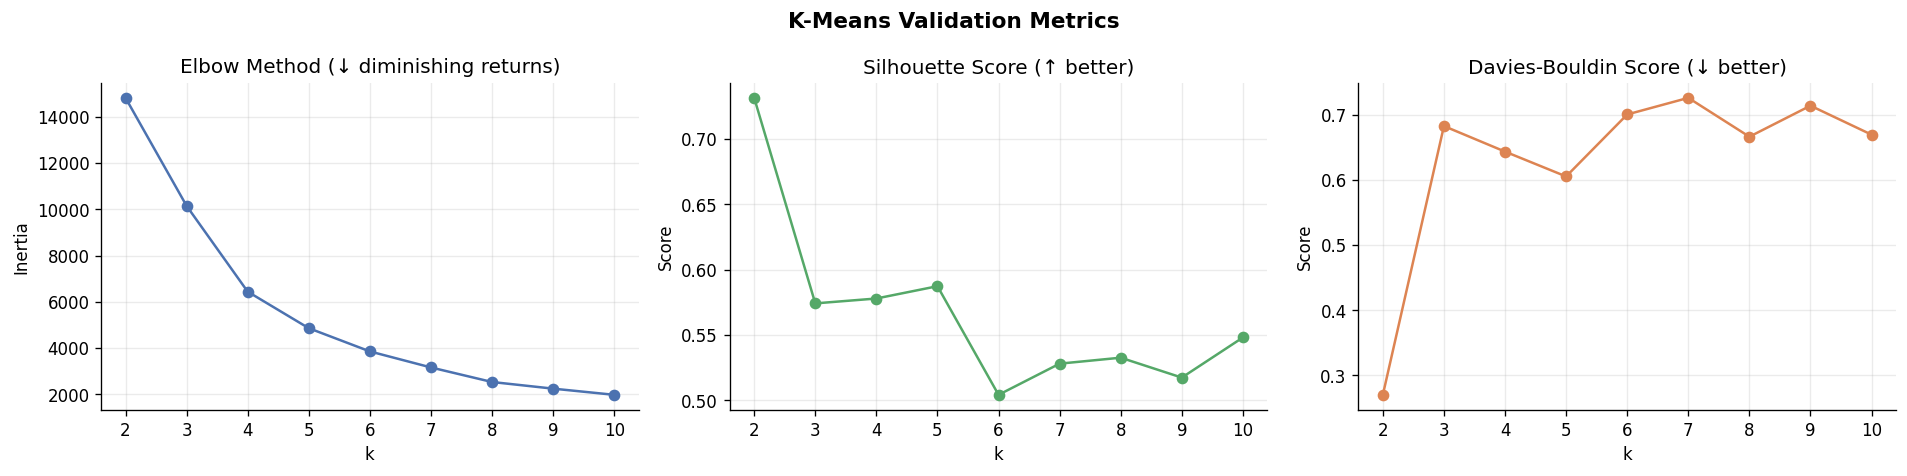

In [136]:
k_range = range(2, 11)

inertias, silhouette_scores_list, db_scores, ch_scores = [], [], [], []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores_list.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

kmeans_metrics = pd.DataFrame({
    'k': list(k_range),
    'inertia': inertias,
    'silhouette_score': silhouette_scores_list,
    'davies_bouldin_score': db_scores,
    'calinski_harabasz_score': ch_scores
})

print('K-Means validation metrics:')
display(kmeans_metrics.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('K-Means Validation Metrics', fontsize=13, fontweight='bold')

axes[0].plot(kmeans_metrics['k'], kmeans_metrics['inertia'], marker='o', color='#4C72B0')
axes[0].set_title('Elbow Method (↓ diminishing returns)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(kmeans_metrics['k'], kmeans_metrics['silhouette_score'], marker='o', color='#55A868')
axes[1].set_title('Silhouette Score (↑ better)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')

axes[2].plot(kmeans_metrics['k'], kmeans_metrics['davies_bouldin_score'], marker='o', color='#DD8452')
axes[2].set_title('Davies-Bouldin Score (↓ better)')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Score')

plt.tight_layout()
plt.savefig('kmeans_validation_metrics.png', bbox_inches='tight')
plt.show()

## 7.1Final K-Means Clustering

In [137]:
#K-Means clustering using the strongest validation-supported solution
selected_k = 2

kmeans = KMeans(n_clusters=selected_k, random_state=RANDOM_STATE, n_init=50)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('K-Means cluster sizes:')
display(df['kmeans_cluster'].value_counts().sort_index())

print('K-Means validation:')
print('Silhouette Score:', round(silhouette_score(X_scaled, df['kmeans_cluster']), 4))
print('Davies-Bouldin Score:', round(davies_bouldin_score(X_scaled, df['kmeans_cluster']), 4))
print('Calinski-Harabasz Score:', round(calinski_harabasz_score(X_scaled, df['kmeans_cluster']), 4))

kmeans_profile = df.groupby('kmeans_cluster')[
    ['gene_count', 'onset_count', 'inheritance_count',
     'avg_prevalence', 'log_avg_prevalence', 'data_completeness_score', 'priority_score']
].mean().round(3)

print('K-Means cluster profile:')
display(kmeans_profile)

#  Cluster interpretation based on profile comparison
cluster_labels = {
    c: f'Cluster {c}' for c in range(selected_k)
}

print('\nCluster interpretation based on profile comparison:')
print('With k=2, K-Means separates diseases into two broad groups based on overall feature intensity.')
print('One cluster generally represents lower-information or lower-complexity disease records.')
print('The other cluster generally represents higher-complexity or higher-priority disease records.')
print('Detailed interpretation should be based on the kmeans_profile table above.')

K-Means cluster sizes:


,count
kmeans_cluster,
0,6102
1,1339


K-Means validation:
Silhouette Score: 0.7312
Davies-Bouldin Score: 0.2703
Calinski-Harabasz Score: 11237.9523
K-Means cluster profile:


,gene_count,onset_count,inheritance_count,avg_prevalence,log_avg_prevalence,data_completeness_score,priority_score
kmeans_cluster,,,,,,,
0,1.059,1.0,1.0,15.377,1.304,3.450,0.382
1,0.070,0.0,0.0,0.271,0.030,0.048,0.002



Cluster interpretation based on profile comparison:
With k=2, K-Means separates diseases into two broad groups based on overall feature intensity.
One cluster generally represents lower-information or lower-complexity disease records.
The other cluster generally represents higher-complexity or higher-priority disease records.
Detailed interpretation should be based on the kmeans_profile table above.


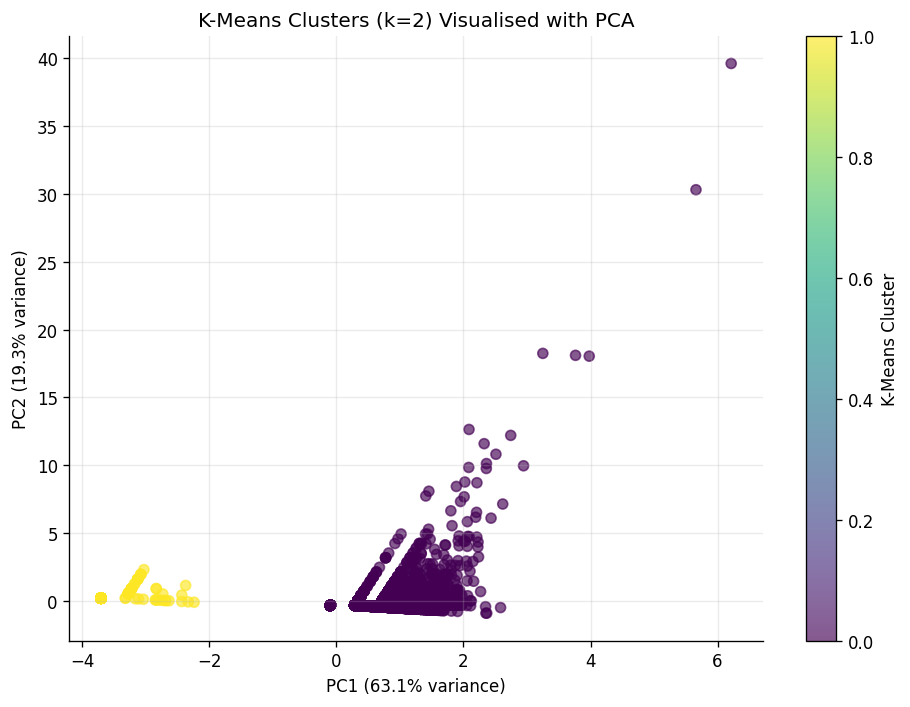

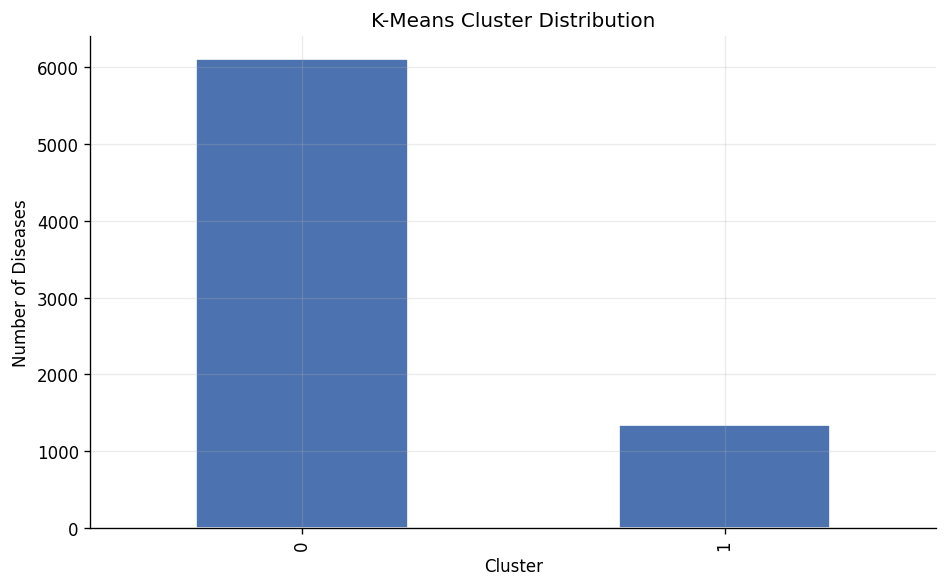

In [138]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df['PC1'], df['PC2'], c=df['kmeans_cluster'],
                      cmap='viridis', alpha=0.65)
plt.title(f'K-Means Clusters (k={selected_k}) Visualised with PCA')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.colorbar(scatter, label='K-Means Cluster')
plt.tight_layout()
plt.savefig('kmeans_pca_clusters.png', bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 5))
df['kmeans_cluster'].value_counts().sort_index().plot(kind='bar', color='#4C72B0', edgecolor='white')
plt.title('K-Means Cluster Distribution')
plt.xlabel('Cluster')
plt.ylabel('Number of Diseases')
plt.tight_layout()
plt.savefig('kmeans_cluster_distribution.png', bbox_inches='tight')
plt.show()

## 7.2 Hierarchical Clustering

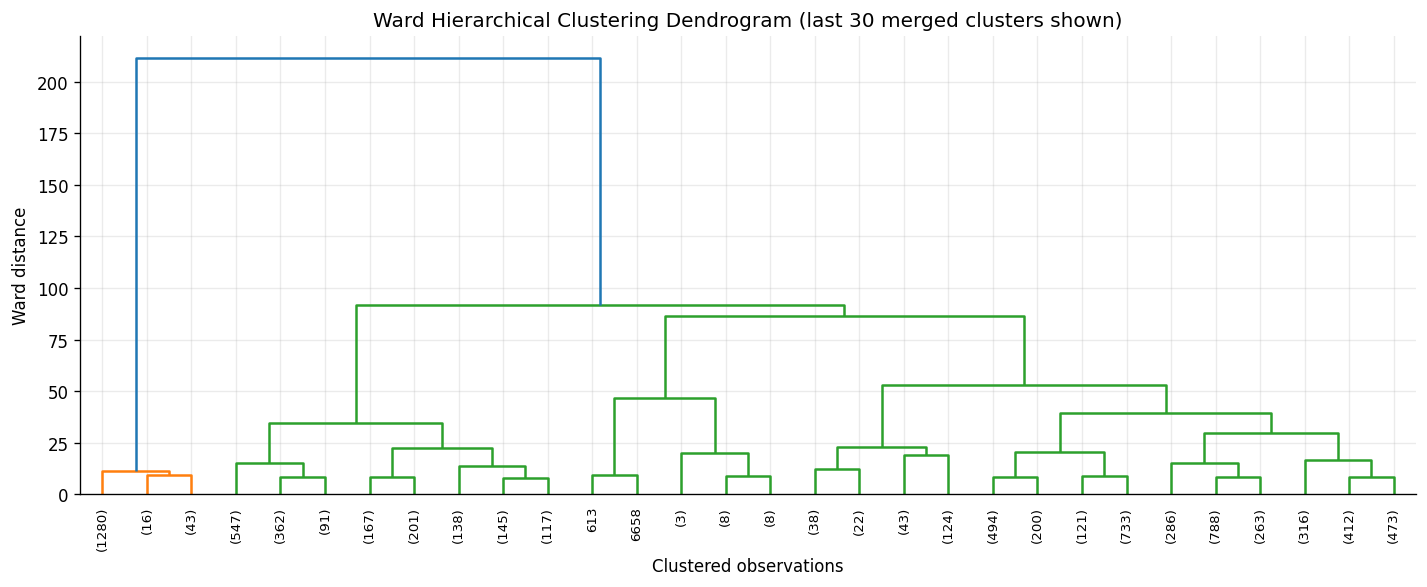

Hierarchical cluster sizes:


,count
hierarchical_cluster,
0,6102
1,1339


Hierarchical validation:
Silhouette Score: 0.7312
Davies-Bouldin Score: 0.2703
Calinski-Harabasz Score: 11237.9523
Hierarchical cluster profile:


,gene_count,onset_count,inheritance_count,avg_prevalence,log_avg_prevalence,data_completeness_score,priority_score
hierarchical_cluster,,,,,,,
0,1.059,1.0,1.0,15.377,1.304,3.450,0.382
1,0.070,0.0,0.0,0.271,0.030,0.048,0.002


In [139]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=8)
plt.title('Ward Hierarchical Clustering Dendrogram (last 30 merged clusters shown)')
plt.xlabel('Clustered observations')
plt.ylabel('Ward distance')
plt.tight_layout()
plt.savefig('hierarchical_dendrogram.png', bbox_inches='tight')
plt.show()

hierarchical = AgglomerativeClustering(n_clusters=selected_k, linkage='ward')
df['hierarchical_cluster'] = hierarchical.fit_predict(X_scaled)

print('Hierarchical cluster sizes:')
display(df['hierarchical_cluster'].value_counts().sort_index())

print('Hierarchical validation:')
print('Silhouette Score:', round(silhouette_score(X_scaled, df['hierarchical_cluster']), 4))
print('Davies-Bouldin Score:', round(davies_bouldin_score(X_scaled, df['hierarchical_cluster']), 4))
print('Calinski-Harabasz Score:', round(calinski_harabasz_score(X_scaled, df['hierarchical_cluster']), 4))

hierarchical_profile = df.groupby('hierarchical_cluster')[
    ['gene_count', 'onset_count', 'inheritance_count',
     'avg_prevalence', 'log_avg_prevalence', 'data_completeness_score', 'priority_score']
].mean().round(3)

print('Hierarchical cluster profile:')
display(hierarchical_profile)

## 7.3. Cluster Comparison (K-Means vs Hierarchical)

In [140]:
cluster_comparison = pd.crosstab(df['kmeans_cluster'], df['hierarchical_cluster'])

print('K-Means vs Hierarchical cluster comparison:')
display(cluster_comparison)

ari = adjusted_rand_score(df['kmeans_cluster'], df['hierarchical_cluster'])
nmi = normalized_mutual_info_score(df['kmeans_cluster'], df['hierarchical_cluster'])

print('\nAdjusted Rand Index:', round(ari, 4),
      '  (1.0 = perfect agreement, 0 = random)')
print('Normalized Mutual Information:', round(nmi, 4),
      '  (1.0 = identical partitions)')
print('\nHigh ARI/NMI indicates whether K-Means and Hierarchical clustering agree on the broad cluster structure.')

K-Means vs Hierarchical cluster comparison:


hierarchical_cluster,0,1
kmeans_cluster,,
0,6102,0
1,0,1339



Adjusted Rand Index: 1.0   (1.0 = perfect agreement, 0 = random)
Normalized Mutual Information: 1.0   (1.0 = identical partitions)

High ARI/NMI indicates whether K-Means and Hierarchical clustering agree on the broad cluster structure.


# **8. GMM with Covariance Type Exploration**


In [141]:
# GMM evaluation across covariance types and cluster counts
cov_types = ['full', 'tied', 'diag', 'spherical']
k_range_gmm = range(2, 16)

gmm_all_results = []

for cov_type in cov_types:
    for k in k_range_gmm:
        try:
            gmm_temp = GaussianMixture(
                n_components=k,
                covariance_type=cov_type,
                random_state=RANDOM_STATE,
                n_init=10,
                max_iter=200
            )
            gmm_temp.fit(X_scaled)
            labels_temp = gmm_temp.predict(X_scaled)
            sil = silhouette_score(X_scaled, labels_temp) if len(set(labels_temp)) > 1 else -1

            gmm_all_results.append({
                'covariance_type': cov_type,
                'k': k,
                'aic': gmm_temp.aic(X_scaled),
                'bic': gmm_temp.bic(X_scaled),
                'silhouette_score': sil
            })

        except Exception:
            pass

gmm_all_metrics = pd.DataFrame(gmm_all_results)

print('GMM covariance type comparison (BIC summary):')
display(
    gmm_all_metrics.groupby('covariance_type')[
        ['bic', 'silhouette_score']
    ].agg({'bic': 'min', 'silhouette_score': 'max'}).round(4)
)

best_row = gmm_all_metrics.loc[gmm_all_metrics['bic'].idxmin()]

print(f'\nBest GMM configuration by BIC: k={int(best_row["k"])}, covariance_type={best_row["covariance_type"]}')
print(f'BIC={best_row["bic"]:.2f}, Silhouette={best_row["silhouette_score"]:.4f}')

GMM covariance type comparison (BIC summary):


,bic,silhouette_score
covariance_type,,
diag,-326780.3897,0.7312
full,-325597.7961,0.7312
spherical,-112037.1827,0.7185
tied,-160288.4792,0.7396



Best GMM configuration by BIC: k=15, covariance_type=diag
BIC=-326780.39, Silhouette=0.3356


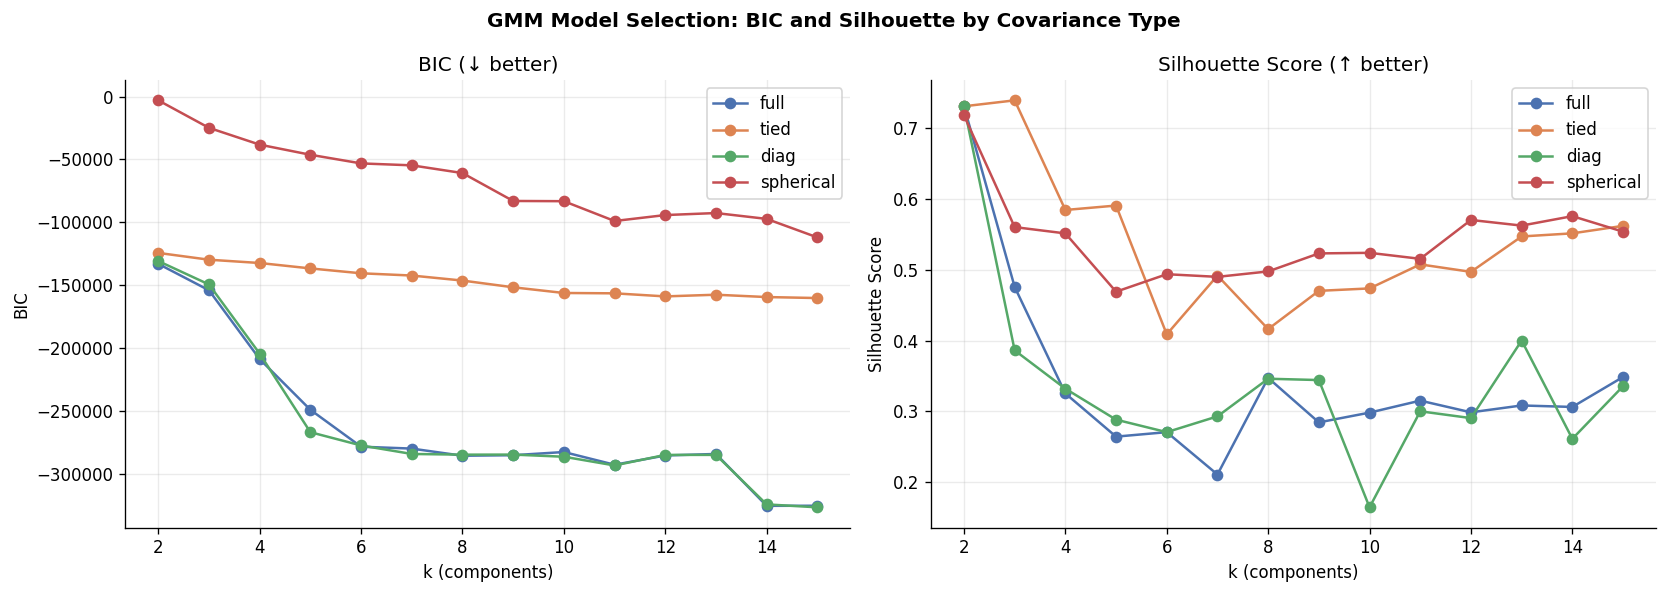

In [142]:
# GMM model selection curves by covariance type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GMM Model Selection: BIC and Silhouette by Covariance Type', fontweight='bold')

colors = {'full': '#4C72B0', 'tied': '#DD8452', 'diag': '#55A868', 'spherical': '#C44E52'}

for cov_type in cov_types:
    subset = gmm_all_metrics[gmm_all_metrics['covariance_type'] == cov_type]
    axes[0].plot(subset['k'], subset['bic'], marker='o', label=cov_type,
                 color=colors[cov_type])
    axes[1].plot(subset['k'], subset['silhouette_score'], marker='o', label=cov_type,
                 color=colors[cov_type])

axes[0].set_title('BIC (↓ better)')
axes[0].set_xlabel('k (components)')
axes[0].set_ylabel('BIC')
axes[0].legend()

axes[1].set_title('Silhouette Score (↑ better)')
axes[1].set_xlabel('k (components)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('gmm_model_selection_covariance_types.png', bbox_inches='tight')
plt.show()

In [143]:
# Final GMM fitting using the selected configuration
best_gmm_k    = int(best_row['k'])
best_cov_type = best_row['covariance_type']

# Guard: if best_k is at the edge of search space, warn
if best_gmm_k >= max(k_range_gmm) - 1:
    print(f'WARNING: BIC selected k={best_gmm_k} which is near the upper boundary of the search space.')
    print('Consider extending the search range further.')
    # Fall back to a more interpretable k for the business context
    best_gmm_k = 4
    print(f'Falling back to k={best_gmm_k} for interpretability.')

print(f'Fitting final GMM: k={best_gmm_k}, covariance_type={best_cov_type}')

gmm = GaussianMixture(
    n_components=best_gmm_k,
    covariance_type=best_cov_type,
    random_state=RANDOM_STATE,
    n_init=20,
    max_iter=300
)
df['gmm_cluster'] = gmm.fit_predict(X_scaled)

gmm_probabilities = gmm.predict_proba(X_scaled)
df['gmm_membership_confidence'] = gmm_probabilities.max(axis=1)

print('GMM cluster sizes:')
display(df['gmm_cluster'].value_counts().sort_index())

gmm_profile = df.groupby('gmm_cluster')[
    ['gene_count', 'onset_count', 'inheritance_count', 'avg_prevalence',
     'log_avg_prevalence', 'data_completeness_score', 'priority_score',
     'gmm_membership_confidence']
].mean().round(3)

print('GMM cluster profile:')
display(gmm_profile)

Consider extending the search range further.
Falling back to k=4 for interpretability.
Fitting final GMM: k=4, covariance_type=diag
GMM cluster sizes:


,count
gmm_cluster,
0,937
1,1339
2,3034
3,2131


GMM cluster profile:


,gene_count,onset_count,inheritance_count,avg_prevalence,log_avg_prevalence,data_completeness_score,priority_score,gmm_membership_confidence
gmm_cluster,,,,,,,,
0,0.622,1.0,1.0,52.769,2.243,3.000,0.400,0.954
1,0.070,0.0,0.0,0.271,0.030,0.048,0.002,1.000
2,1.938,1.0,1.0,13.989,1.596,4.000,0.408,1.000
3,0.000,1.0,1.0,0.911,0.474,2.866,0.337,0.932


# **9.Anomaly Detection**

In [144]:
#Sensitivity analysis for the Isolation Forest contamination parameter

contamination_values = [0.01, 0.02, 0.05]
print('Sensitivity to contamination parameter:')
print(f'{"Contamination":<15}  {"Anomalies flagged":<20}  {"% of dataset"}')
for cont in contamination_values:
    iso_test = IsolationForest(n_estimators=300, contamination=cont, random_state=RANDOM_STATE)
    labels_test = iso_test.fit_predict(X_scaled)
    n_anom = (labels_test == -1).sum()
    print(f'{cont:<15}  {n_anom:<20}  {n_anom/len(df)*100:.2f}%')

print('\nSelected contamination = 0.02 (see markdown justification above)')

Sensitivity to contamination parameter:
Contamination    Anomalies flagged     % of dataset
0.01             75                    1.01%
0.02             149                   2.00%
0.05             372                   5.00%

Selected contamination = 0.02 (see markdown justification above)


In [145]:
#Final Isolation Forest model for anomaly detection
isolation_model = IsolationForest(
    n_estimators=300,
    contamination=0.02,
    random_state=RANDOM_STATE
)

df['anomaly_label'] = isolation_model.fit_predict(X_scaled)
df['anomaly_score']  = isolation_model.decision_function(X_scaled)
df['is_anomaly']     = (df['anomaly_label'] == -1).astype(int)

print('Anomaly flag counts:')
display(df['is_anomaly'].value_counts())

anomaly_profile = df.groupby('is_anomaly')[
    ['gene_count', 'onset_count', 'inheritance_count', 'avg_prevalence',
     'log_avg_prevalence', 'data_completeness_score', 'priority_score']
].mean().round(3)

print('Anomaly profile:')
display(anomaly_profile)

top_anomalies = df.sort_values('anomaly_score').head(25)[
    ['OrphaCode', 'Name', 'gene_count', 'onset_count',
     'inheritance_count', 'avg_prevalence', 'priority_score',
     'kmeans_cluster', 'is_anomaly', 'anomaly_score']
]

print('Top anomalies (lowest anomaly scores = most anomalous):')
display(top_anomalies)

Anomaly flag counts:


,count
is_anomaly,
0,7292
1,149


Anomaly profile:


,gene_count,onset_count,inheritance_count,avg_prevalence,log_avg_prevalence,data_completeness_score,priority_score
is_anomaly,,,,,,,
0,0.670,0.824,0.824,9.362,1.063,2.840,0.314
1,11.215,0.617,0.617,173.987,1.629,2.765,0.311


Top anomalies (lowest anomaly scores = most anomalous):


,OrphaCode,Name,gene_count,onset_count,inheritance_count,avg_prevalence,priority_score,kmeans_cluster,is_anomaly,anomaly_score
613,791,Retinitis pigmentosa,88,1,1,22.254444,0.722662,0,1,-0.098885
195,244,Primary ciliary dyskinesia,53,1,1,24.500000,0.618209,0,1,-0.096727
4532,178342,Inflammatory myofibroblastic tumor,6,0,0,0.000000,0.043421,1,1,-0.092413
413,536,Systemic lupus erythematosus,30,1,1,35.980000,0.559702,0,1,-0.089872
124,154,Familial isolated dilated cardiomyopathy,53,1,1,8.803333,0.587072,0,1,-0.087655
3781,98944,Coloboma of iris,5,0,0,0.000000,0.040351,1,1,-0.085690
7174,675396,Epithelioid hemangioma,5,0,0,0.000000,0.040351,1,1,-0.085690
4706,213711,Endometrial stromal sarcoma,5,0,0,0.000000,0.040351,1,1,-0.085690
6658,528084,Non-specific syndromic intellectual disability,114,1,1,0.000000,0.700000,0,1,-0.082890
3782,98945,Coloboma of macula,4,0,0,0.000000,0.037281,1,1,-0.082624


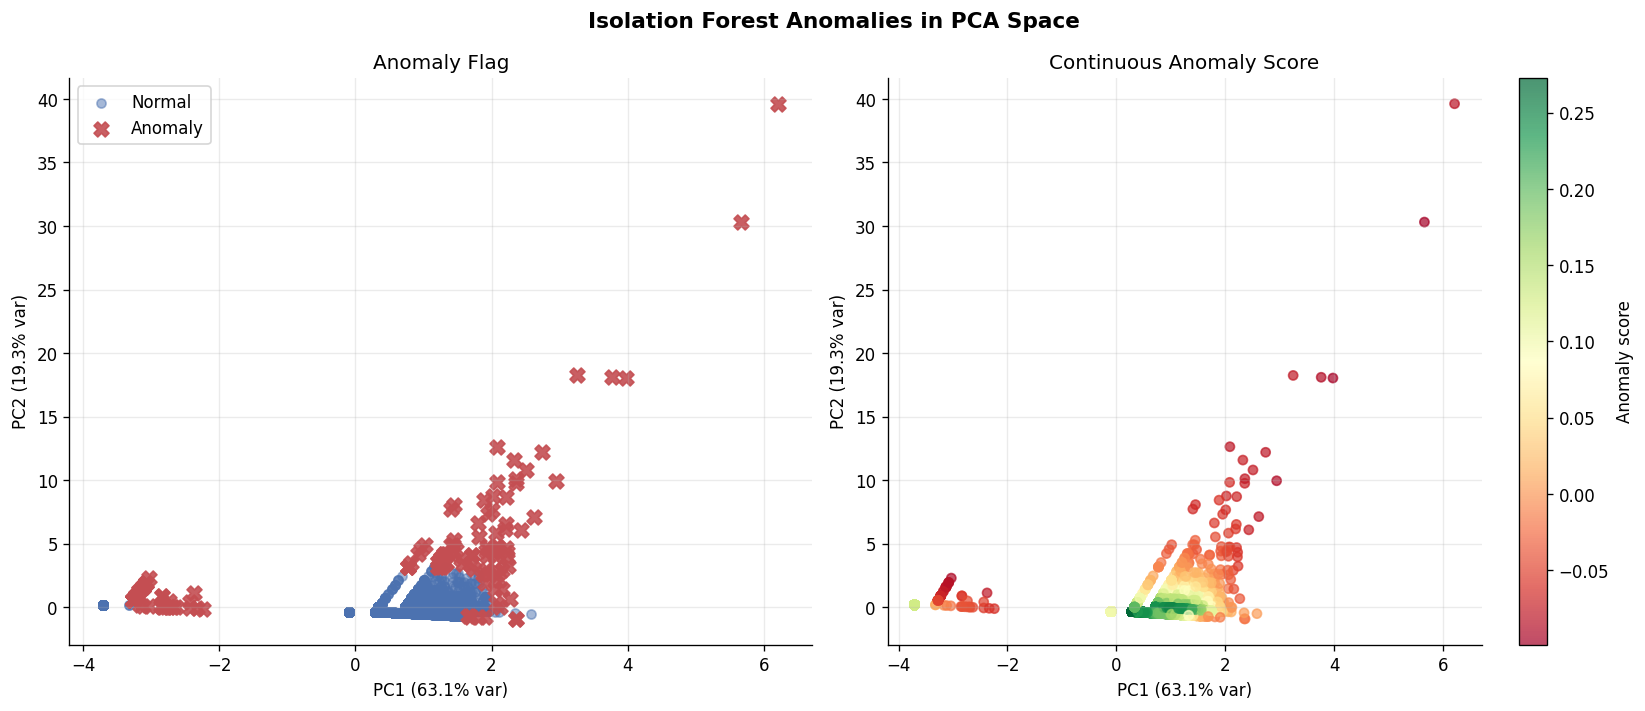

In [146]:
# PCA visualization of Isolation Forest anomaly results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Isolation Forest Anomalies in PCA Space', fontsize=13, fontweight='bold')

normal = df[df['is_anomaly'] == 0]
anom = df[df['is_anomaly'] == 1]

axes[0].scatter(
    normal['PC1'],
    normal['PC2'],
    alpha=0.5,
    color='#4C72B0',
    label='Normal',
    s=30
)

axes[0].scatter(
    anom['PC1'],
    anom['PC2'],
    alpha=0.9,
    color='#C44E52',
    label='Anomaly',
    s=80,
    marker='X'
)

axes[0].set_title('Anomaly Flag')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
axes[0].legend()

sc = axes[1].scatter(
    df['PC1'],
    df['PC2'],
    c=df['anomaly_score'],
    cmap='RdYlGn',
    alpha=0.7,
    s=30
)

plt.colorbar(sc, ax=axes[1], label='Anomaly score')
axes[1].set_title('Continuous Anomaly Score')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')

plt.tight_layout()
plt.savefig('isolation_forest_pca.png', bbox_inches='tight')
plt.show()

## 9.1 Clustering Without Anomalies

Dataset without anomalies: 7292 records (removed 149 anomalies)

Silhouette Score (full dataset, k=2):  0.7312
Silhouette Score (no anomalies, k=2): 0.7004

Change in silhouette after removing anomalies: -0.0309

Cluster profile after removing anomalies:


,gene_count,avg_prevalence,data_completeness_score,priority_score
kmeans_cluster_clean,,,,
0,0.813,11.359,3.445,0.381
1,0.000,0.000,0.002,0.000


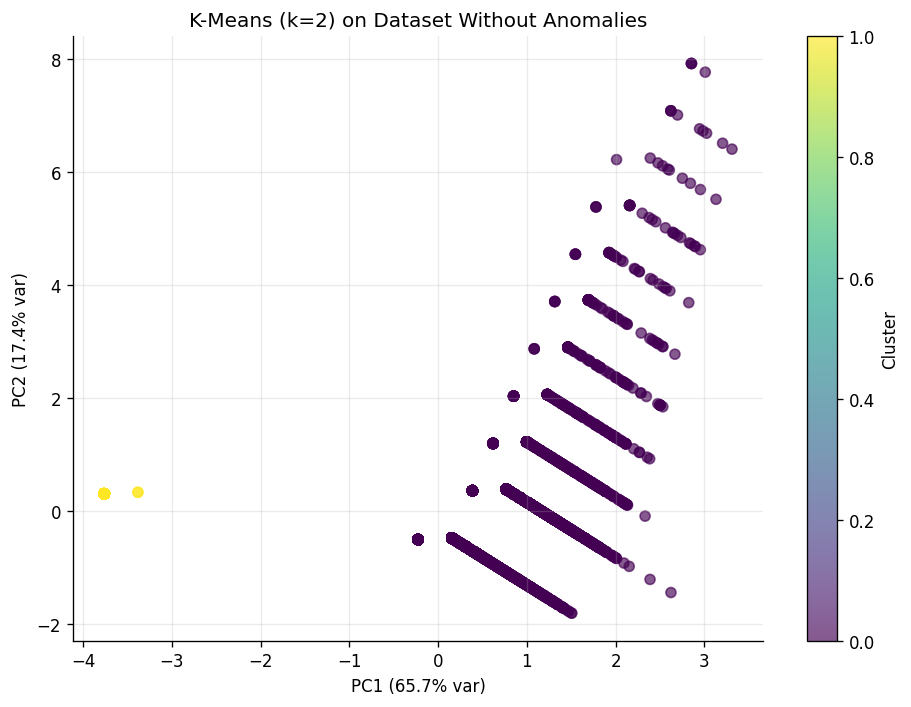

In [147]:
# Clustering after removing anomaly records
df_clean = df[df['is_anomaly'] == 0].copy()
df_clean.reset_index(drop=True, inplace=True)

X_clean = df_clean[model_features]

scaler_clean = StandardScaler()
X_clean_scaled = scaler_clean.fit_transform(X_clean)

print(f'Dataset without anomalies: {len(df_clean)} records (removed {len(df) - len(df_clean)} anomalies)')

kmeans_clean = KMeans(n_clusters=selected_k, random_state=RANDOM_STATE, n_init=50)
df_clean['kmeans_cluster_clean'] = kmeans_clean.fit_predict(X_clean_scaled)

sil_full = silhouette_score(X_scaled, df['kmeans_cluster'])
sil_clean = silhouette_score(X_clean_scaled, df_clean['kmeans_cluster_clean'])

print(f'\nSilhouette Score (full dataset, k={selected_k}):  {sil_full:.4f}')
print(f'Silhouette Score (no anomalies, k={selected_k}): {sil_clean:.4f}')
difference = round(sil_clean - sil_full, 4)
print('\nChange in silhouette after removing anomalies:', difference)

clean_profile = df_clean.groupby('kmeans_cluster_clean')[
    ['gene_count', 'avg_prevalence', 'data_completeness_score', 'priority_score']
].mean().round(3)

print('\nCluster profile after removing anomalies:')
display(clean_profile)

pca_clean = PCA(n_components=2, random_state=RANDOM_STATE)
pca_clean_coords = pca_clean.fit_transform(X_clean_scaled)

df_clean['PC1_clean'] = pca_clean_coords[:, 0]
df_clean['PC2_clean'] = pca_clean_coords[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(
    df_clean['PC1_clean'],
    df_clean['PC2_clean'],
    c=df_clean['kmeans_cluster_clean'],
    cmap='viridis',
    alpha=0.65
)

plt.title(f'K-Means (k={selected_k}) on Dataset Without Anomalies')
plt.xlabel(f'PC1 ({pca_clean.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PC2 ({pca_clean.explained_variance_ratio_[1]:.1%} var)')
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.savefig('kmeans_no_anomalies_pca.png', bbox_inches='tight')
plt.show()

# **10. Regression**


In [148]:
# Regression setup without prevalence-based leakage
df['data_completeness_noleak'] = (
    df['has_gene_data'] +
    df['has_onset_data'] +
    df['has_inheritance_data']
)

reg_features_clean = [
    'gene_count',
    'onset_count',
    'inheritance_count',
    'data_completeness_noleak'
]

target = 'log_avg_prevalence'

X_reg = df[reg_features_clean]
y_reg = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print('Regression setup:')
print(f'  Features: {reg_features_clean}')
print(f'  Target: {target} (log-transformed prevalence)')
print(f'  Train size: {len(X_train)}, Test size: {len(X_test)}')
print(f'  Target range: {y_reg.min():.2f} to {y_reg.max():.2f}')
print(f'  Target median: {y_reg.median():.2f}')

Regression setup:
  Features: ['gene_count', 'onset_count', 'inheritance_count', 'data_completeness_noleak']
  Target: log_avg_prevalence (log-transformed prevalence)
  Train size: 5952, Test size: 1489
  Target range: 0.00 to 9.21
  Target median: 0.69


In [149]:
# Linear Regression baseline model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

print('Linear Regression coefficients:')
for feat, coef in zip(reg_features_clean, linear_model.coef_):
    print(f'  {feat:<30}: {coef:.4f}')
print(f'  Intercept: {linear_model.intercept_:.4f}')

Linear Regression coefficients:
  gene_count                    : 0.0031
  onset_count                   : 0.2235
  inheritance_count             : 0.2235
  data_completeness_noleak      : 0.3299
  Intercept: 0.0150


In [150]:
# Random Forest hyperparameter tuning with cross-validation
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 5, 8],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt', 'log2']
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid,
    cv=cv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print('Best Random Forest parameters from GridSearchCV:')
print(best_params)

rf_model = grid_search.best_estimator_
rf_pred  = rf_model.predict(X_test)

regression_results = pd.DataFrame({
    'model': ['Linear Regression', 'Random Forest (tuned)'],
    'MAE':  [mean_absolute_error(y_test, linear_pred),
             mean_absolute_error(y_test, rf_pred)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, linear_pred)),
             np.sqrt(mean_squared_error(y_test, rf_pred))],
    'R2':   [r2_score(y_test, linear_pred),
             r2_score(y_test, rf_pred)]
})

print('\nRegression results (target = log_avg_prevalence, no leakage):')
display(regression_results.round(4))

feature_importance = pd.DataFrame({
    'feature': reg_features_clean,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print('\nRandom Forest feature importance:')
display(feature_importance)

Best Random Forest parameters from GridSearchCV:
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 100}

Regression results (target = log_avg_prevalence, no leakage):


,model,MAE,RMSE,R2
0,Linear Regression,0.9126,1.2205,0.1369
1,Random Forest (tuned),0.9103,1.2207,0.1366



Random Forest feature importance:


,feature,importance
1,onset_count,0.346440
2,inheritance_count,0.292545
3,data_completeness_noleak,0.289218
0,gene_count,0.071797


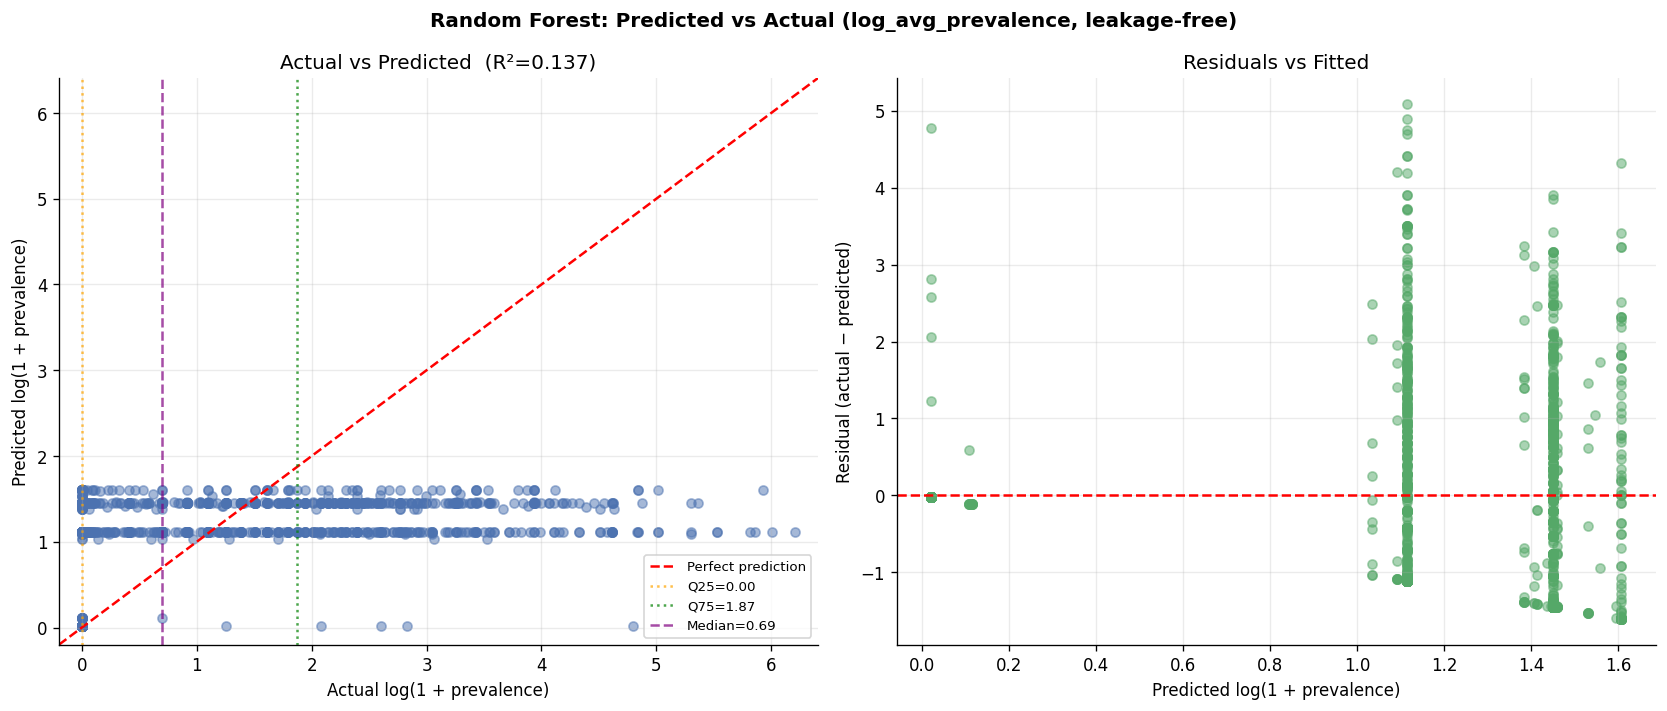

Target variable range context:
  log_avg_prevalence = 0 means avg_prevalence = 0 (no data or truly zero prevalence)
  log_avg_prevalence = 1 means avg_prevalence ≈ 1.7 per million
  log_avg_prevalence = 5 means avg_prevalence ≈ 147 per million
  Median in test set: 0.69 (≈ 1.0 per million)


In [151]:
#Regression visualization with target range and residual patterns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Random Forest: Predicted vs Actual (log_avg_prevalence, leakage-free)',
             fontsize=12, fontweight='bold')

#actual vs predicted with reference lines
y_min = min(y_test.min(), rf_pred.min()) - 0.2
y_max = max(y_test.max(), rf_pred.max()) + 0.2

axes[0].scatter(y_test, rf_pred, alpha=0.5, color='#4C72B0', s=30)
axes[0].plot([y_min, y_max], [y_min, y_max], 'r--', lw=1.5, label='Perfect prediction')

q25, q75 = np.percentile(y_test, [25, 75])
axes[0].axvline(q25, color='orange', linestyle=':', alpha=0.7, label=f'Q25={q25:.2f}')
axes[0].axvline(q75, color='green',  linestyle=':', alpha=0.7, label=f'Q75={q75:.2f}')
axes[0].axvline(y_test.median(), color='purple', linestyle='--', alpha=0.7, label=f'Median={y_test.median():.2f}')

axes[0].set_xlim(y_min, y_max)
axes[0].set_ylim(y_min, y_max)
axes[0].set_title(f'Actual vs Predicted  (R²={r2_score(y_test, rf_pred):.3f})')
axes[0].set_xlabel('Actual log(1 + prevalence)')
axes[0].set_ylabel('Predicted log(1 + prevalence)')
axes[0].legend(fontsize=8)

#residuals plot
residuals = y_test.values - rf_pred
axes[1].scatter(rf_pred, residuals, alpha=0.5, color='#55A868', s=30)
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Residuals vs Fitted')
axes[1].set_xlabel('Predicted log(1 + prevalence)')
axes[1].set_ylabel('Residual (actual − predicted)')

plt.tight_layout()
plt.savefig('rf_actual_vs_predicted_improved.png', bbox_inches='tight')
plt.show()

print(f'Target variable range context:')
print(f'  log_avg_prevalence = 0 means avg_prevalence = 0 (no data or truly zero prevalence)')
print(f'  log_avg_prevalence = 1 means avg_prevalence ≈ 1.7 per million')
print(f'  log_avg_prevalence = 5 means avg_prevalence ≈ 147 per million')
print(f'  Median in test set: {y_test.median():.2f} (≈ {np.expm1(y_test.median()):.1f} per million)')

# **11. Final Priority Segments**

In [152]:
df['priority_segment'] = pd.qcut(
    df['priority_score'],
    q=[0, 0.50, 0.80, 0.95, 1.00],
    labels=[
        'Low Priority',
        'Moderate Priority',
        'High Priority',
        'Critical Priority'
    ],)
final_columns = [
    'OrphaCode', 'Name', 'DisorderGroup',
    'gene_count', 'onset_count', 'inheritance_count',
    'avg_prevalence', 'log_avg_prevalence',
    'has_prevalence_data', 'data_completeness_score',
    'priority_score', 'priority_rank', 'priority_segment',
    'kmeans_cluster', 'hierarchical_cluster',
    'gmm_cluster', 'gmm_membership_confidence',
    'is_anomaly', 'anomaly_score'
]

final_df = df[final_columns].sort_values('priority_rank')

print('Final prioritization dataset (top 30):')
display(final_df.head(30))

Final prioritization dataset (top 30):


,OrphaCode,Name,DisorderGroup,gene_count,onset_count,inheritance_count,avg_prevalence,log_avg_prevalence,has_prevalence_data,data_completeness_score,priority_score,priority_rank,priority_segment,kmeans_cluster,hierarchical_cluster,gmm_cluster,gmm_membership_confidence,is_anomaly,anomaly_score
613,791,Retinitis pigmentosa,Disorder,88,1,1,22.254444,3.146496,1,4,0.722662,1,Critical Priority,0,0,2,1.0,1,-0.098885
6658,528084,Non-specific syndromic intellectual disability,Disorder,114,1,1,0.000000,0.000000,1,4,0.700000,2,Critical Priority,0,0,2,1.0,1,-0.082890
4799,227972,Toxic oil syndrome,Disorder,0,1,1,10000.000000,9.210440,1,3,0.625000,3,Critical Priority,0,0,0,1.0,1,-0.017700
5558,319218,Ebola hemorrhagic fever,Disorder,0,1,1,9406.666667,9.149280,1,3,0.623008,4,Critical Priority,0,0,0,1.0,1,-0.017700
4126,103909,Trehalase deficiency,Disorder,1,1,1,3850.000000,8.256088,1,4,0.621985,5,Critical Priority,0,0,2,1.0,0,0.002981
195,244,Primary ciliary dyskinesia,Disorder,53,1,1,24.500000,3.238678,1,4,0.618209,6,Critical Priority,0,0,2,1.0,1,-0.096727
6303,454745,Kuru,Disorder,1,1,1,1350.000000,7.208600,1,4,0.587867,7,Critical Priority,0,0,2,1.0,0,0.003272
124,154,Familial isolated dilated cardiomyopathy,Disorder,53,1,1,8.803333,2.282722,1,4,0.587072,8,Critical Priority,0,0,2,1.0,1,-0.087655
1571,2309,Pachyonychia congenita,Disorder,4,1,1,500.045000,6.216696,1,4,0.564769,9,Critical Priority,0,0,2,1.0,1,-0.037084
413,536,Systemic lupus erythematosus,Disorder,30,1,1,35.980000,3.610377,1,4,0.559702,10,Critical Priority,0,0,2,1.0,1,-0.089872


# **12. Final Summaries**

In [153]:
priority_summary = final_df.groupby('priority_segment', observed=False).agg(
    disease_count=('OrphaCode', 'count'),
    avg_gene_count=('gene_count', 'mean'),
    avg_prevalence=('avg_prevalence', 'mean'),
    avg_priority_score=('priority_score', 'mean'),
    anomaly_count=('is_anomaly', 'sum')).round(3)

print('Priority segment summary:')
display(priority_summary)

cluster_summary = final_df.groupby('kmeans_cluster').agg(
    disease_count=('OrphaCode', 'count'),
    avg_gene_count=('gene_count', 'mean'),
    avg_prevalence=('avg_prevalence', 'mean'),
    avg_priority_score=('priority_score', 'mean'),
    anomaly_count=('is_anomaly', 'sum')).round(3)

print('K-Means cluster summary:')
display(cluster_summary)

Priority segment summary:


,disease_count,avg_gene_count,avg_prevalence,avg_priority_score,anomaly_count
priority_segment,,,,,
Low Priority,3737,0.276,0.259,0.215,61
Moderate Priority,2216,1.205,3.235,0.386,25
High Priority,1116,1.395,20.636,0.441,16
Critical Priority,372,3.487,169.420,0.497,47


K-Means cluster summary:


,disease_count,avg_gene_count,avg_prevalence,avg_priority_score,anomaly_count
kmeans_cluster,,,,,
0,6102,1.059,15.377,0.382,92
1,1339,0.070,0.271,0.002,57


## 22. Export Output Files

In [154]:
final_df.to_csv('rare_diseases_final_prioritization_dataset.csv', index=False)
priority_summary.to_csv('priority_summary.csv')
cluster_summary.to_csv('cluster_summary.csv')
kmeans_metrics.to_csv('kmeans_validation_metrics.csv', index=False)
gmm_all_metrics.to_csv('gmm_validation_metrics_all_covariance_types.csv', index=False)
regression_results.to_csv('regression_results.csv', index=False)

print('Exported files:')
print('  rare_diseases_final_prioritization_dataset.csv')
print('  priority_summary.csv')
print('  cluster_summary.csv')
print('  kmeans_validation_metrics.csv')
print('  gmm_validation_metrics_all_covariance_types.csv')
print('  regression_results.csv')

print('\nFiles in current directory:')
print(os.listdir())

Exported files:
  rare_diseases_final_prioritization_dataset.csv
  priority_summary.csv
  cluster_summary.csv
  kmeans_validation_metrics.csv
  gmm_validation_metrics_all_covariance_types.csv
  regression_results.csv

Files in current directory:
['.config', 'correlation_per_aggregation_level.png', 'kmeans_validation_metrics.csv', 'priority_summary.csv', 'rf_actual_vs_predicted_improved.png', 'kmeans_no_anomalies_pca.png', 'pca_unclustered.png', 'rare_diseases_final_prioritization_dataset.csv', 'isolation_forest_pca.png', 'regression_results.csv', 'log_prevalence_distribution.png', 'kmeans_validation_metrics.png', 'correlation_heatmap.png', 'gmm_model_selection_covariance_types.png', 'kmeans_cluster_distribution.png', 'hierarchical_dendrogram.png', 'kmeans_pca_clusters.png', 'eda_main_distributions.png', 'cluster_summary.csv', 'priority_score_distribution.png', 'gmm_validation_metrics_all_covariance_types.csv', 'sample_data']


In [155]:
try:
    from google.colab import files

    files.download('rare_diseases_final_prioritization_dataset.csv')
    files.download('priority_summary.csv')
    files.download('cluster_summary.csv')
    files.download('kmeans_validation_metrics.csv')
    files.download('gmm_validation_metrics_all_covariance_types.csv')
    files.download('regression_results.csv')

except Exception as e:
    print('Download step skipped. This is normal if you are not using Google Colab.')
    print('Reason:', e)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>